<a href="https://colab.research.google.com/github/iarithik/VQE-Molecular-GroundState-Sim/blob/main/VQE_Molecular_GroundState_Sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Done state: notebook runs without errors

This tutorial is created using the resources:
1. https://pennylane.ai/qml/demos/tutorial_vqe
2.

We start with installing all the libraries which we will need for this tutorial on VQE

In [ ]:
pip install jax pennylane optax matplotlib --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 73.9 MB/s eta 0:00:00


## Loading the H2 dataset

In [ ]:
from jax import numpy as np
import jax
jax.config.update("jax_platform_name", "cpu")
jax.config.update('jax_enable_x64', True)

import pennylane as qml

dataset = qml.data.load('qchem', molname="H2")[0]
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)
print("Number of qubits = ", qubits)
print("The Hamiltonian is ", H)

Number of qubits =  4
The Hamiltonian is  -0.09963387941370971 * I(0) + 0.17110545123720233 * Z(0) + 0.17110545123720225 * Z(1) + 0.16859349595532533 * (Z(0) @ Z(1)) + 0.04533062254573469 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.04533062254573469 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.04533062254573469 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.04533062254573469 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.22250914236600539 * Z(2) + 0.12051027989546245 * (Z(0) @ Z(2)) + -0.22250914236600539 * Z(3) + 0.16584090244119712 * (Z(0) @ Z(3)) + 0.16584090244119712 * (Z(1) @ Z(2)) + 0.12051027989546245 * (Z(1) @ Z(3)) + 0.1743207725924201 * (Z(2) @ Z(3))


Above you can see we used `jax`, which we use for better numerical calculations and `x64` is for 64 bit precisions during calculations (i.e. 15 to 16 digits of accuracy after the decimals).\
We are also loading the dataset called `qchem` using the function `load` and getting the data about the molecule `H2` from it.\
The number of qubits depends upon the considered basis set. Here we use the minimal basis set approximation to represent our orbitals. What it means is, that we are representing the electron probability cloud around our `H2 molecule` using some minimal functions, known as `STO-G2 set` (or the `STO-G3 set`). This is the set of linear combination of gaussian functions of two (if `STO-G2 set`) or three (if `STO-G3 set`).


Basis: minimal basis set approximation\
In this approximation, we have four spin orbitals, which defines the number of qubits.

### Molecular Orbital Theory

Below is the energy level diagram of the isolated H atoms and also of the H2 molecule. Since each of the H atom has only 1 electron, so it will have electron probability cloud defined by the 1s orbital (which looks like a sphere as shown in the mid left and mid right H atom diagrams).\


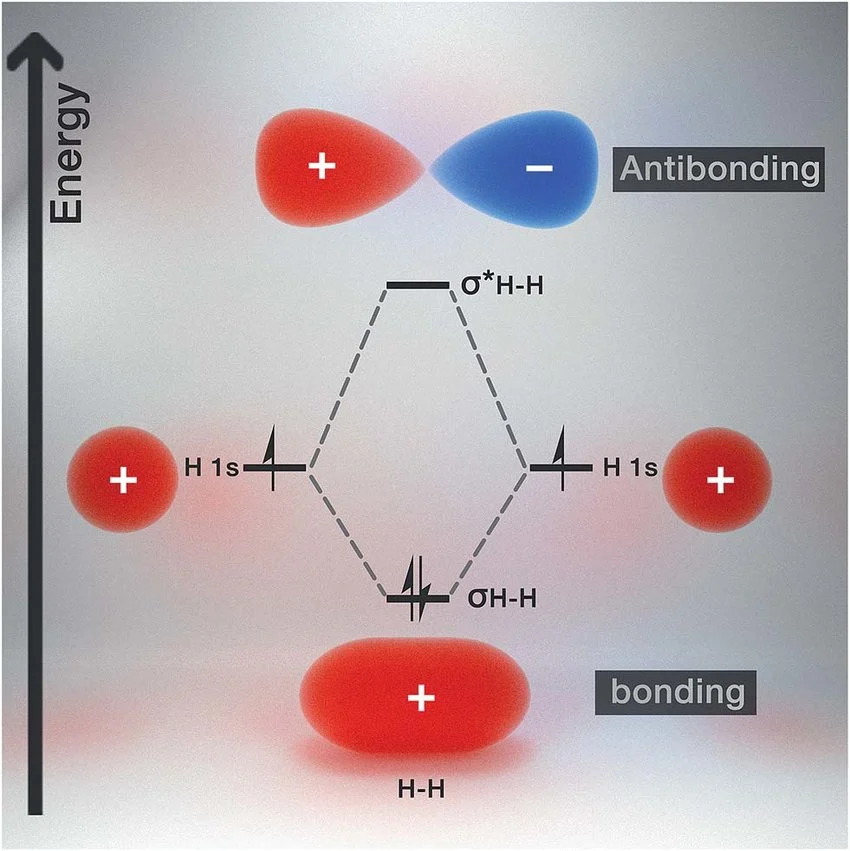\
source:https://www.researchgate.net/figure/Diagram-of-the-molecular-orbitals-of-the-hydrogen-molecule_fig14_270663139

## Connecting the qml device

In [ ]:
dev = qml.device("lightning.qubit", wires=qubits)

In [ ]:
electrons = 2
hf = qml.qchem.hf_state(electrons, qubits)
print(hf)

[1 1 0 0]


In [ ]:
@qml.qnode(dev, interface="jax")
def circuit(param, wires):
    qml.BasisState(hf, wires=wires)
    qml.DoubleExcitation(param, wires=[0, 1, 2, 3])
    return qml.expval(H)

In [ ]:
def cost_fn(param):
    return circuit(param, wires=range(qubits))

In [ ]:
import optax

max_iterations = 100
conv_tol = 1e-06

opt = optax.sgd(learning_rate=0.4)

In [ ]:
theta = np.array(0.)

# store the values of the cost function
energy = [cost_fn(theta)]

# store the values of the circuit parameter
angle = [theta]

opt_state = opt.init(theta)

for n in range(max_iterations):

    gradient = jax.grad(cost_fn)(theta)
    updates, opt_state = opt.update(gradient, opt_state)
    theta = optax.apply_updates(theta, updates)

    angle.append(theta)
    energy.append(cost_fn(theta))

    conv = np.abs(energy[-1] - energy[-2])

    if n % 2 == 0:
        print(f"Step = {n},  Energy = {energy[-1]:.8f} Ha")

    if conv <= conv_tol:
        break

print("\n" f"Final value of the ground-state energy = {energy[-1]:.8f} Ha")
print("\n" f"Optimal value of the circuit parameter = {angle[-1]:.4f}")

Step = 0,  Energy = -1.12772109 Ha
Step = 2,  Energy = -1.13524628 Ha
Step = 4,  Energy = -1.13683932 Ha
Step = 6,  Energy = -1.13717430 Ha
Step = 8,  Energy = -1.13724463 Ha
Step = 10,  Energy = -1.13725940 Ha
Step = 12,  Energy = -1.13726250 Ha

Final value of the ground-state energy = -1.13726250 Ha

Optimal value of the circuit parameter = 0.2250


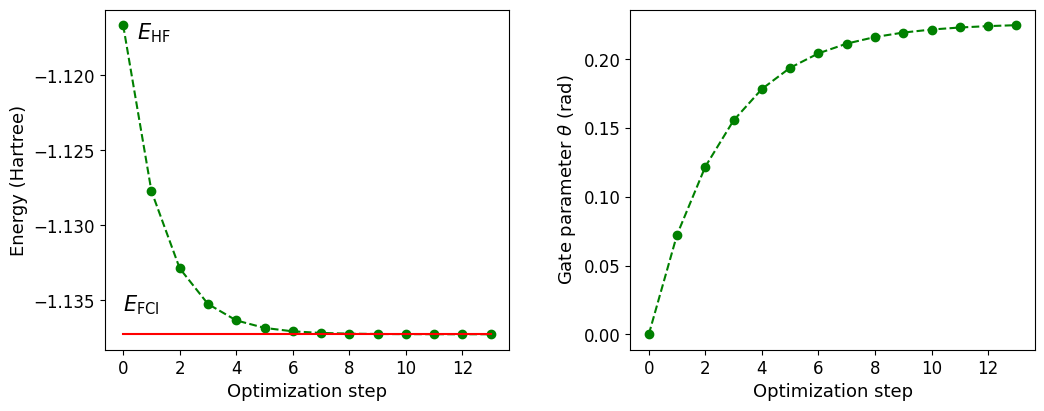

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = dataset.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()